<a href="https://colab.research.google.com/github/sridharparshana/python_projects/blob/myones/Linkedin_Job_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
joykimaiyo18_linkedin_data_jobs_dataset_path = kagglehub.dataset_download('joykimaiyo18/linkedin-data-jobs-dataset')

print('Data source import complete.')


Data source import complete.


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/linkedin-data-jobs-dataset/clean_jobs.csv


**Import Libraries:**

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

**Load Dataset:**

In [5]:
try:
    df = pd.read_csv('/kaggle/input/linkedin-data-jobs-dataset/clean_jobs.csv')
    print("✅ Data Loaded Successfully")
    print("Shape of dataset:", df.shape)
    print("\n🔍 Columns Available:")
    print(df.columns.tolist())
except Exception as e:
    print(f"❌ Error loading data: {str(e)}")
    exit()


✅ Data Loaded Successfully
Shape of dataset: (618, 10)

🔍 Columns Available:
['id', 'title', 'company', 'location', 'link', 'source', 'date_posted', 'work_type', 'employment_type', 'description']


**EDA:**

In [6]:
def plot_distributions():
    # Plot settings
    plt.figure(figsize=(15, 12))

    # 1. Job Titles
    plt.subplot(2, 2, 1)
    if 'title' in df.columns:
        title_counts = df['title'].value_counts().nlargest(10)
        sns.barplot(y=title_counts.index, x=title_counts.values, palette='Blues_d')
        plt.title('Top 10 Job Titles')
        plt.xlabel('Count')

    # 2. Companies
    plt.subplot(2, 2, 2)
    if 'company' in df.columns:
        company_counts = df['company'].value_counts().nlargest(10)
        sns.barplot(y=company_counts.index, x=company_counts.values, palette='Greens_d')
        plt.title('Top 10 Companies')
        plt.xlabel('Count')

    # 3. Work Types
    plt.subplot(2, 2, 3)
    if 'work_type' in df.columns and df['work_type'].notna().any():
        work_type_counts = df['work_type'].value_counts()
        sns.barplot(y=work_type_counts.index, x=work_type_counts.values, palette='Purples_d')
        plt.title('Work Type Distribution')
        plt.xlabel('Count')
    else:
        plt.text(0.5, 0.5, 'No Work Type Data', ha='center', va='center')
        plt.axis('off')

    # 4. Employment Types
    plt.subplot(2, 2, 4)
    if 'employment_type' in df.columns and df['employment_type'].notna().any():
        employment_counts = df['employment_type'].value_counts()
        sns.barplot(y=employment_counts.index, x=employment_counts.values, palette='Oranges_d')
        plt.title('Employment Type Distribution')
        plt.xlabel('Count')
    else:
        plt.text(0.5, 0.5, 'No Employment Type Data', ha='center', va='center')
        plt.axis('off')

    plt.tight_layout()
    plt.show()



**Data Preprocessing:**

In [7]:
print("\n🔍 Data Preprocessing...")

# 1. Create Target Variable (Engineering jobs)
df['target'] = df['title'].apply(
    lambda x: 1 if any(keyword in str(x).lower()
                      for keyword in ['engineer', 'developer', 'software', 'programmer'])
    else 0
)

print("\n🎯 Target Distribution:")
print(df['target'].value_counts())
print(f"\nPercentage of Engineering Jobs: {df['target'].mean():.2%}")

# 2. Handle Missing Data
print("\n🔄 Handling Missing Values:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Fill missing categorical data with 'Unknown'
categorical_cols = ['work_type', 'employment_type', 'company', 'location']
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')


🔍 Data Preprocessing...

🎯 Target Distribution:
target
0    396
1    222
Name: count, dtype: int64

Percentage of Engineering Jobs: 35.92%

🔄 Handling Missing Values:
work_type          618
employment_type    618
description          4
dtype: int64


**Feature Engineering:**

In [10]:
# Extract features from date_posted if available
if 'date_posted' in df.columns:
    df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')
    df['posting_day'] = df['date_posted'].dt.day_name()
    df['posting_month'] = df['date_posted'].dt.month_name()

# Feature Selection
categorical_features = ['work_type', 'employment_type', 'company', 'location']
if 'posting_day' in df.columns:
    categorical_features.extend(['posting_day', 'posting_month'])

text_feature = 'description'
numerical_features = []

# Encode categorical features
for col in categorical_features:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Handle missing text
df[text_feature] = df[text_feature].fillna('')

# Prepare features
X_categorical = df[categorical_features]
X_text = df[text_feature]
y = df['target']

# TF-IDF transform text
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

text_transformer = TfidfVectorizer(max_features=1000, stop_words='english')
X_text_transformed = text_transformer.fit_transform(X_text)

# Combine categorical and text features
X_processed = hstack([X_categorical.values, X_text_transformed])


**Train-Test Split:**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n📊 Train/Test Split:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")


📊 Train/Test Split:
Training samples: 432
Test samples: 186


**Model Evaluation & Training:**


🏋️ Training Logistic Regression...
✅ Logistic Regression trained successfully
Accuracy: 0.9570

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       119
           1       0.98      0.90      0.94        67

    accuracy                           0.96       186
   macro avg       0.96      0.94      0.95       186
weighted avg       0.96      0.96      0.96       186



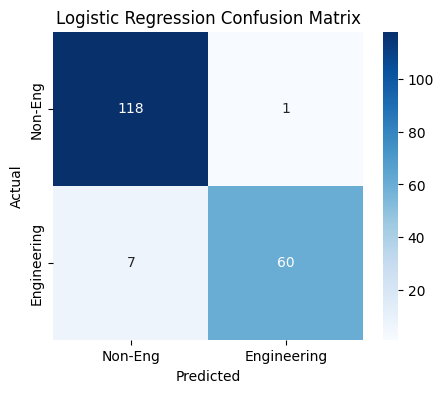


🏋️ Training Random Forest...
✅ Random Forest trained successfully
Accuracy: 0.9677

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       119
           1       0.97      0.94      0.95        67

    accuracy                           0.97       186
   macro avg       0.97      0.96      0.96       186
weighted avg       0.97      0.97      0.97       186



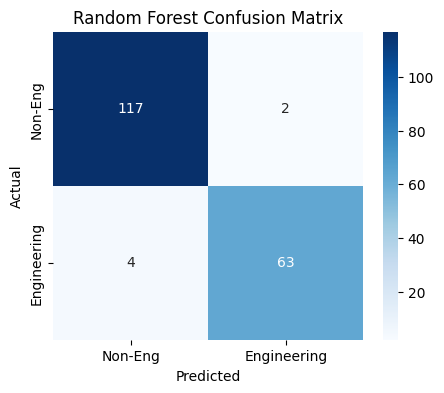


🏋️ Training XGBoost...
✅ XGBoost trained successfully
Accuracy: 0.9247

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       119
           1       0.91      0.88      0.89        67

    accuracy                           0.92       186
   macro avg       0.92      0.92      0.92       186
weighted avg       0.92      0.92      0.92       186



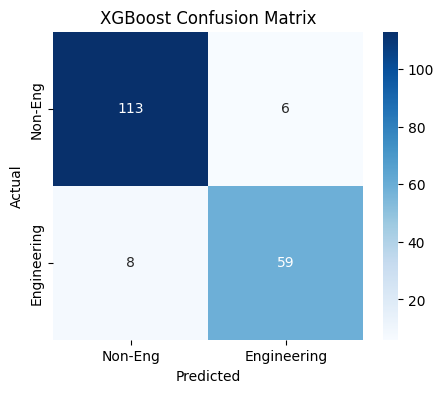


🏋️ Training SVM...
✅ SVM trained successfully
Accuracy: 0.9462

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       119
           1       0.93      0.93      0.93        67

    accuracy                           0.95       186
   macro avg       0.94      0.94      0.94       186
weighted avg       0.95      0.95      0.95       186



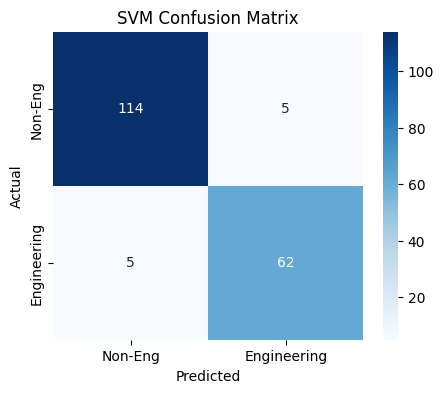

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC(probability=True, kernel='linear')
}

results = {}

for name, model in models.items():
    try:
        print(f"\n🏋️ Training {name}...")
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = accuracy

        print(f"✅ {name} trained successfully")
        print(f"Accuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        # Plot confusion matrix
        plt.figure(figsize=(5, 4))
        sns.heatmap(confusion_matrix(y_test, y_pred),
                   annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Non-Eng', 'Engineering'],
                   yticklabels=['Non-Eng', 'Engineering'])
        plt.title(f'{name} Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

    except Exception as e:
        print(f"❌ Error in {name}: {str(e)}")

**Result Comparison:**

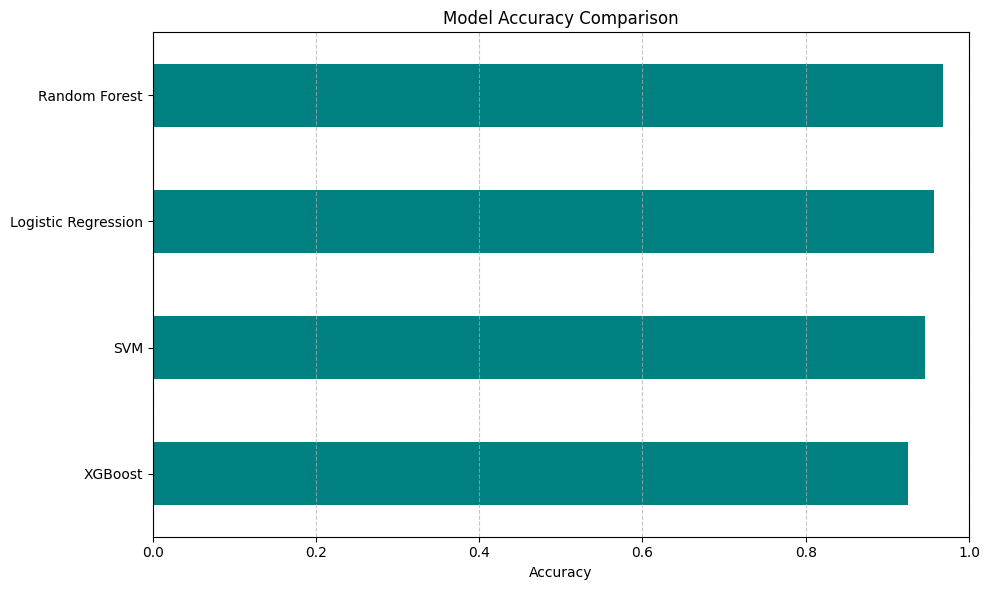


🏆 Best Performing Model: Random Forest (Accuracy: 0.9677)


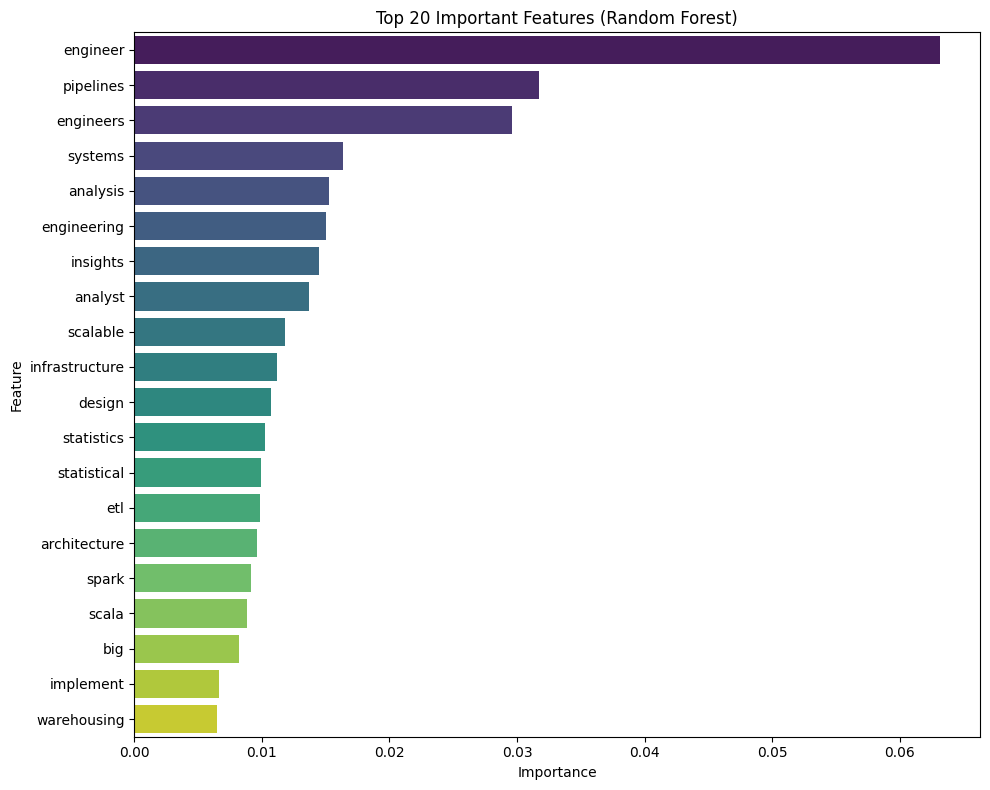


✅ Analysis Complete!


In [13]:
if results:
    plt.figure(figsize=(10, 6))
    pd.Series(results).sort_values().plot(kind='barh', color='teal')
    plt.title('Model Accuracy Comparison')
    plt.xlabel('Accuracy')
    plt.xlim(0, 1)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    best_model_name = max(results, key=results.get)
    print(f"\n🏆 Best Performing Model: {best_model_name} (Accuracy: {results[best_model_name]:.4f})")
else:
    print("\n❌ No models were successfully trained")

# ========================== #
#       Feature Importance
# ========================== #
try:
    if "Random Forest" in models:
        importances = models["Random Forest"].feature_importances_

        # Get feature names
        feature_names = categorical_features + text_transformer.get_feature_names_out().tolist()

        # Create importance DataFrame
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False).head(20)

        # Plot
        plt.figure(figsize=(10, 8))
        sns.barplot(y='Feature', x='Importance', data=importance_df, palette='viridis')
        plt.title('Top 20 Important Features (Random Forest)')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"\n⚠️ Could not plot feature importance: {str(e)}")

print("\n✅ Analysis Complete!")